# Component 1 — Credit readiness: review and retrain

Findings about `digital legder.ipynb` and the saved `component1_sales_financial_model.pkl`, and a corrected model:

1. **The data is synthetic with a known label formula**, so the best possible score (the *oracle*) can be computed.
   Results are reported against that ceiling.
2. **The saved model does not use `months_active` as a feature.** Numeric columns were chosen with
   `select_dtypes(include=['int64', 'float64'])`; in the run that produced the `.pkl`, `months_active` was not
   `int64`, so it was silently dropped (the pipeline has 14 inputs instead of 15). It is the strongest factor in the
   label formula. This notebook selects numeric columns with `select_dtypes('number')`.
3. **The loan-limit regressor learns a formula.** Its target is exactly `3.5 × net_cash_flow`; the formula itself is
   exact and explainable, so the ML service now uses the formula.
4. **Rules:** in this data `debt_to_income_ratio = 1 − margin`, so the "DTI > 85 %" rule means "margin < 15 %".

`digital legder.ipynb`, `sales & financial.csv` and the original `.pkl` are not changed. The corrected model is
saved as `component1_sales_financial_model_v2.pkl`.

In [1]:
import warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, r2_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
RANDOM_STATE = 42


def add_domain_features(X_df):
    """Same feature engineering as digital legder.ipynb (also used by ml_service/app.py)."""
    X_out = X_df.copy()
    rev = np.maximum(X_out['monthly_revenue_rs'], 1.0) if 'monthly_revenue_rs' in X_out.columns else 1.0
    exp = X_out['monthly_expenses_rs'] if 'monthly_expenses_rs' in X_out.columns else 0.0
    active_m = np.maximum(X_out['months_active'], 1.0) if 'months_active' in X_out.columns else 1.0
    dig_ratio = X_out['digital_payment_ratio'] if 'digital_payment_ratio' in X_out.columns else 0.0
    X_out['net_cash_flow'] = rev - exp
    X_out['debt_to_income_ratio'] = exp / rev
    X_out['digital_revenue_volume'] = rev * dig_ratio
    X_out['revenue_per_active_month'] = rev / active_m
    X_out['cash_flow_margin'] = X_out['net_cash_flow'] / rev
    return X_out

## 1. Data, the known label formula, and the oracle ceiling

In [2]:
df = pd.read_csv('sales & financial.csv').drop_duplicates().reset_index(drop=True)
df = df.drop(columns=['shop_id', 'year_month'], errors='ignore')
X_raw = df.drop(columns=['target_credit_ready'])
y = df['target_credit_ready'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
print(f'Rows {len(df)} | credit-ready rate {y.mean():.3f} | train {len(X_train)} / test {len(X_test)}')

# The generating formula from digital legder.ipynb (cell 1): label = 1 if sigmoid(score - median) > uniform noise
def true_score(d):
    return (0.05 * d['profit_margin_pct'] + 0.09 * d['months_active'] + 2.0 * d['digital_payment_ratio']
            - 3.5 * d['stockout_rate'] - 1.5 * d['credit_sales_ratio'] - 0.15 * d['sales_volatility'])

baseline = np.median(true_score(X_raw))
oracle_p = 1 / (1 + np.exp(-(true_score(X_test) - baseline)))
ORACLE_AUC, ORACLE_ACC = roc_auc_score(y_test, oracle_p), accuracy_score(y_test, oracle_p >= 0.5)
print(f'ORACLE (true formula) on the test set: ROC-AUC {ORACLE_AUC:.3f} | accuracy {ORACLE_ACC:.3f}')

effect = pd.Series({'months_active': 0.09, 'profit_margin_pct': 0.05, 'digital_payment_ratio': 2.0,
                    'stockout_rate': -3.5, 'credit_sales_ratio': -1.5, 'sales_volatility': -0.15})
effect = (effect * X_raw[effect.index].std()).sort_values(key=abs, ascending=False)
print('\nEffect of each factor in the formula (weight × std):'); print(effect.round(2).to_string())
print('\nNot used by the formula at all: monthly_revenue_rs, monthly_expenses_rs, monthly_profit_rs, avg_daily_txns')

Rows 2500 | credit-ready rate 0.480 | train 2000 / test 500
ORACLE (true formula) on the test set: ROC-AUC 0.840 | accuracy 0.760

Effect of each factor in the formula (weight × std):
months_active            0.94
profit_margin_pct        0.76
stockout_rate           -0.71
digital_payment_ratio    0.53
credit_sales_ratio      -0.22
sales_volatility        -0.21

Not used by the formula at all: monthly_revenue_rs, monthly_expenses_rs, monthly_profit_rs, avg_daily_txns


Because the label contains random noise, **no model can exceed the oracle** (about 0.84 AUC / 0.76 accuracy).
Model results should be read as a share of this ceiling.

## 2. The saved model is missing `months_active`

In [3]:
saved = joblib.load('component1_sales_financial_model.pkl')
saved_num = saved['classifier_pipeline'].named_steps['prep'].transformers_[0][2]
print('months_active among the saved model inputs:', 'months_active' in saved_num)
print('Number of inputs to the saved classifier   :', saved['classifier_pipeline'].named_steps['clf'].n_features_in_)
p_saved = saved['classifier_pipeline'].predict_proba(X_test)[:, 1]
print(f'Saved model on the test set: ROC-AUC {roc_auc_score(y_test, p_saved):.3f} | accuracy {accuracy_score(y_test, p_saved >= 0.5):.3f}')

months_active among the saved model inputs: False
Number of inputs to the saved classifier   : 14
Saved model on the test set: ROC-AUC 0.816 | accuracy 0.686


## 3. Retrain with all numeric inputs (`select_dtypes('number')`)

In [4]:
engineered = add_domain_features(X_raw)
num_cols = engineered.select_dtypes('number').columns.tolist()     # int32/int64/float all included
print(f'{len(num_cols)} numeric inputs, months_active included: {"months_active" in num_cols}')

def pipeline(estimator):
    pre = ColumnTransformer([('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num_cols)])
    return Pipeline([('feat_eng', FunctionTransformer(add_domain_features, validate=False)), ('prep', pre), ('clf', estimator)])

estimators = {
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'DecisionTree': DecisionTreeClassifier(max_depth=6, min_samples_leaf=5, class_weight='balanced', random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=250, learning_rate=0.05, max_depth=4, subsample=0.85, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.85, colsample_bytree=0.85,
                             eval_metric='logloss', random_state=RANDOM_STATE),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_auc = {}
for name, est in estimators.items():
    s = cross_validate(pipeline(est), X_train, y_train, cv=cv, scoring=['roc_auc', 'accuracy'], n_jobs=-1)
    cv_auc[name] = s['test_roc_auc'].mean()
    print(f"  {name:18s} | CV ROC-AUC {s['test_roc_auc'].mean():.3f} ± {s['test_roc_auc'].std():.3f} | CV acc {s['test_accuracy'].mean():.3f}")
best_name = max(cv_auc, key=cv_auc.get)
print(f'\nChampion (CV only): {best_name}')

15 numeric inputs, months_active included: True


  LogisticRegression | CV ROC-AUC 0.815 ± 0.023 | CV acc 0.747
  DecisionTree       | CV ROC-AUC 0.711 ± 0.028 | CV acc 0.676


  RandomForest       | CV ROC-AUC 0.785 ± 0.028 | CV acc 0.710


  GradientBoosting   | CV ROC-AUC 0.786 ± 0.024 | CV acc 0.706


  XGBoost            | CV ROC-AUC 0.781 ± 0.022 | CV acc 0.709

Champion (CV only): LogisticRegression


In [5]:
champion = pipeline(clone(estimators[best_name])).fit(X_train, y_train)
p_new = champion.predict_proba(X_test)[:, 1]
summary = pd.DataFrame({
    'ROC-AUC': [roc_auc_score(y_test, p_saved), roc_auc_score(y_test, p_new), ORACLE_AUC],
    'Accuracy': [accuracy_score(y_test, p_saved >= .5), accuracy_score(y_test, p_new >= .5), ORACLE_ACC],
    'F1': [f1_score(y_test, p_saved >= .5), f1_score(y_test, p_new >= .5), f1_score(y_test, oracle_p >= .5)],
}, index=['Saved model (no months_active)', f'Retrained {best_name}', 'Oracle (true formula)'])
summary['% of oracle AUC'] = (summary['ROC-AUC'] / ORACLE_AUC * 100).round(1)
summary.round(3)

,ROC-AUC,Accuracy,F1,% of oracle AUC
Saved model (no months_active),0.816,0.686,0.572,97.2
Retrained LogisticRegression,0.839,0.758,0.753,99.9
Oracle (true formula),0.840,0.760,0.756,100.0


## 4. Are the scores trustworthy as probabilities? (calibration)

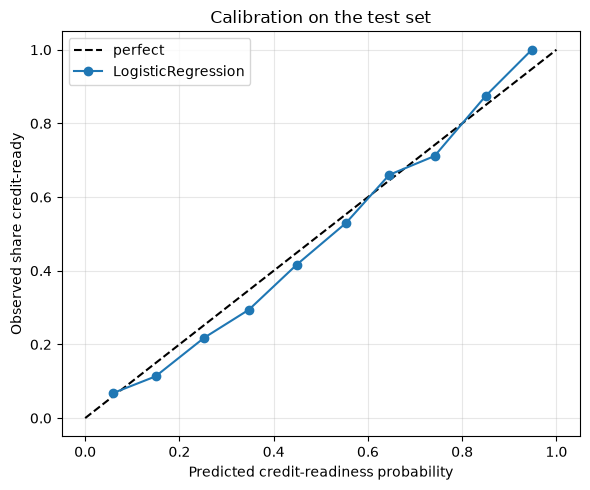

In [6]:
frac, mean_pred = calibration_curve(y_test, p_new, n_bins=10)
plt.figure(figsize=(6, 5))
plt.plot([0, 1], [0, 1], 'k--', label='perfect')
plt.plot(mean_pred, frac, 'o-', label=best_name)
plt.xlabel('Predicted credit-readiness probability'); plt.ylabel('Observed share credit-ready')
plt.title('Calibration on the test set'); plt.legend(); plt.grid(alpha=.3); plt.tight_layout()
plt.savefig('component1_calibration.png', dpi=120); plt.show()

## 5. Loan limit: learned model vs the formula it learns

In [7]:
eng_test = add_domain_features(X_test[y_test == 1])
formula_limit = np.maximum(0, eng_test['net_cash_flow'] * 3.5)
rf_limit = saved['regressor_pipeline'].predict(X_test[y_test == 1])
print(f'Target in digital legder.ipynb = max(0, net_cash_flow x 3.5)')
print(f'  RandomForest regressor : R² {r2_score(formula_limit, rf_limit):.3f} | MAE LKR {mean_absolute_error(formula_limit, rf_limit):,.0f}')
print(f'  The formula itself     : R² 1.000 | MAE LKR 0 (exact and explainable)')

Target in digital legder.ipynb = max(0, net_cash_flow x 3.5)
  RandomForest regressor : R² 0.984 | MAE LKR 1,868
  The formula itself     : R² 1.000 | MAE LKR 0 (exact and explainable)


The ML service now computes the loan limit directly as **3.5 × monthly net cash flow** (rounded to LKR 1,000,
capped at LKR 250,000 for conditional approvals), and returns the basis so the app can show it.

## 6. The DTI rule in this data

In [8]:
dti = X_raw['monthly_expenses_rs'] / X_raw['monthly_revenue_rs']
print('DTI == 1 - margin:', np.isclose(dti, 1 - X_raw['profit_margin_pct'] / 100, atol=0.01).mean())
print(f"'DTI > 85%' blocks {(dti > 0.85).mean():.1%} of shops  == 'margin < 15%': {(X_raw['profit_margin_pct'] < 15).mean():.1%}")
print(f"'stockout > 25%' blocks {(X_raw['stockout_rate'] > 0.25).mean():.1%} of shops; 'months < 3' blocks {(X_raw['months_active'] < 3).mean():.1%}")

DTI == 1 - margin: 1.0
'DTI > 85%' blocks 25.4% of shops  == 'margin < 15%': 25.3%
'stockout > 25%' blocks 66.0% of shops; 'months < 3' blocks 5.5%


## 7. Save the corrected model (new file name)

In [9]:
final = pipeline(clone(estimators[best_name])).fit(X_raw, y)
bundle = {
    'classifier_pipeline': final,
    'raw_feature_names': X_raw.columns.tolist(),
    'loan_limit_rule': 'max(0, 3.5 x monthly net cash flow)',
    'evaluation': {'champion': best_name, 'test_auc': round(roc_auc_score(y_test, p_new), 4),
                   'test_accuracy': round(accuracy_score(y_test, p_new >= .5), 4),
                   'oracle_auc': round(ORACLE_AUC, 4), 'oracle_accuracy': round(ORACLE_ACC, 4)},
}
joblib.dump(bundle, 'component1_sales_financial_model_v2.pkl', compress=3)
print('Saved component1_sales_financial_model_v2.pkl ->', bundle['evaluation'])
print('Inputs:', final.named_steps['clf'].n_features_in_, '(months_active included)')

Saved component1_sales_financial_model_v2.pkl -> {'champion': 'LogisticRegression', 'test_auc': 0.8392, 'test_accuracy': 0.758, 'oracle_auc': 0.8398, 'oracle_accuracy': 0.76}
Inputs: 15 (months_active included)
